<div style="
    border: 2px solid #2c3e50;
    border-radius: 12px;
    padding: 20px;
    background-color: #f8f9fa;
    margin: 10px 0 20px 0;
    box-shadow: 0 2px 8px rgba(0,0,0,0.08);
">

  <h1 style="margin: 0; color: #1f3b73; font-size: 28px;">
    Notebook 04 — Shadow Price
  </h1>

  <h2 style="margin: 10px 0 18px 0; color: #34495e; font-size: 20px; font-weight: normal;">
    Python for Operations Research
  </h2>

  <hr style="border: none; border-top: 1px solid #cfd8dc; margin: 15px 0;">

  <p style="margin: 6px 0; font-size: 16px;">
    <b>Amirkabir University of Technology (Tehran Polytechnic)</b>
  </p>

  <p style="margin: 6px 0; font-size: 15px;">
    <b>Prof:</b> Dr. A. Golroo
  </p>

  <p style="margin: 6px 0; font-size: 15px;">
    <b>Mentor:</b> Parsa Sadri
  </p>

</div>


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    0. Problem Definition
  </h2>
</div>

In many real optimization problems, managers are interested not only in the optimal solution but also in understanding:

- Which resources are limiting the system?
- How valuable is an additional unit of a resource?
- Where should we invest to increase capacity?

These questions are answered using **Shadow Prices**.

In this notebook we will learn:

1. What Shadow Price means intuitively
2. The mathematical definition
3. Binding vs Non‑Binding constraints
4. How to extract Shadow Prices from a solver
5. Managerial interpretation of Shadow Prices


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    1. Why Shadow Price is important?
  </h2>
</div>


Suppose a factory produces two products.

Each product requires **machine time** and **raw material**.

Both resources are limited.

After solving the optimization model we obtain the optimal profit.

Now a manager asks an important question:

> If we had **one more unit of machine time**, how much more profit could we make?

This is exactly what the **Shadow Price** measures.

Shadow Price tells us the **marginal value of relaxing a constraint**.


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    2. Mathematical Definition of Shadow Price
  </h2>
</div>

Consider a general Linear Programming problem:

Maximize:

$$
Z = c_1 x_1 + c_2 x_2 + ... + c_n x_n
$$

Subject to:

$$
a_{11}x_1 + a_{12}x_2 + ... + a_{1n}x_n \le b_1
$$

$$
a_{21}x_1 + a_{22}x_2 + ... + a_{2n}x_n \le b_2
$$

$$
x_j \ge 0
$$

---

The **shadow price** of constraint i is defined as:

$$
ShadowPrice_i = \frac{\partial Z^*}{\partial b_i}
$$

Where:

- $ Z^* $ is the optimal objective value
- $ b_i $ is the right‑hand side of constraint i

---

Interpretation:

> Shadow price measures how much the optimal objective value changes if the constraint bound increases by one unit.


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    3. Example Production Problem
  </h2>
</div>


A factory produces two products:

Product A and Product B.

Profit:
$$
A → 30  
$$
$$
B → 20
$$
Constraints:

Machine time:
$$
2A + B ≤ 100
$$
Material:
$$
A + B ≤ 80
$$
Decision variables:

A = number of units of product A  
B = number of units of product B

Objective:

**Maximize** total profit.


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    4. Solving the Optimization Model
  </h2>
</div>


In [1]:
import pulp
import numpy as np
import matplotlib.pyplot as plt

In [2]:
model = pulp.LpProblem("ProductionProblem", pulp.LpMaximize)

A = pulp.LpVariable("A", lowBound=0)
B = pulp.LpVariable("B", lowBound=0)

# objective
model += 30*A + 20*B

# constraints
machine = model.addConstraint(2*A + B <= 100)
material = model.addConstraint(A + B <= 80)

model.solve()

print("Status:", pulp.LpStatus[model.status])

Status: Optimal


In [3]:
print("Optimal production:")

print("A =", A.varValue)
print("B =", B.varValue)

print("Maximum profit =", pulp.value(model.objective))

Optimal production:
A = 20.0
B = 60.0
Maximum profit = 1800.0


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    5. Binding vs Non‑Binding Constraints
  </h2>
</div>


A constraint can be either:

### Binding Constraint

A constraint is **binding** if it is exactly satisfied at the optimal solution.

Mathematically:

$$
a_1 x_1 + a_2 x_2 + ... = b
$$

This means the resource is **fully utilized**.

---

### Non‑Binding Constraint

A constraint is **non‑binding** if some slack remains.

$$
a_1 x_1 + a_2 x_2 + ... < b
$$

This means some of the resource is unused.

---

Important result:

- Binding constraints usually have **positive shadow prices**
- Non‑binding constraints usually have **shadow price = 0**


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    6. Slack Calculation
  </h2>
</div>


In [4]:
machine_slack = 100 - (2*A.varValue + B.varValue)
material_slack = 80 - (A.varValue + B.varValue)

print("Machine slack:", machine_slack)
print("Material slack:", material_slack)

Machine slack: 0.0
Material slack: 0.0


Interpretation:

If slack = 0 → constraint is **binding**

If slack > 0 → constraint is **non‑binding**


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    7. Extracting Shadow Prices
  </h2>
</div>


Most optimization solvers provide the **dual value** (shadow price) for each constraint.

In PuLP we can access it using: **constraint.pi**


In [5]:
for name, constraint in model.constraints.items():
    print("Constraint:", name)
    print("Shadow Price:", constraint.pi)
    print("Slack:", constraint.slack)
    print()

Constraint: _C1
Shadow Price: 10.0
Slack: -0.0

Constraint: _C2
Shadow Price: 10.0
Slack: -0.0



<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    8. Managerial Interpretation
  </h2>
</div>


Suppose the shadow price of the machine constraint is:

10

This means:

> If we increase machine capacity by 1 unit, the optimal profit will increase by approximately 10 units.

This information is extremely useful for decision makers.

Example questions:

- Should we buy another machine?
- Should we increase labor hours?
- Which resource is the bottleneck?


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    9. Visualizing the Effect of Capacity
  </h2>
</div>


We can visualize how profit changes when machine capacity increases.


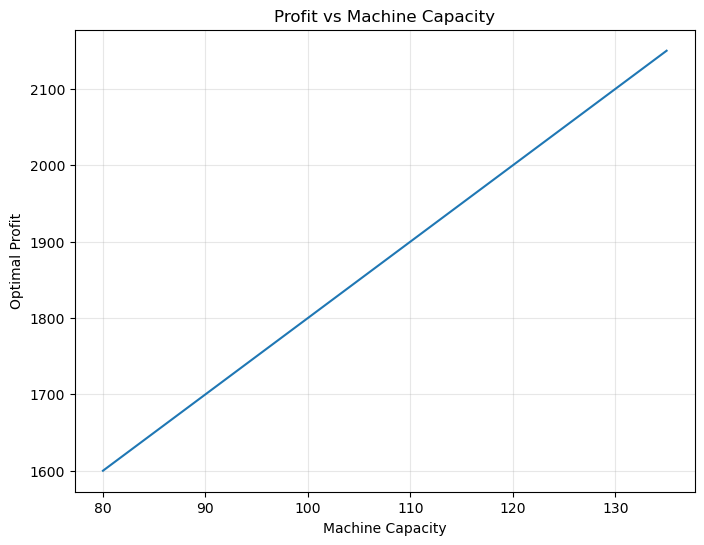

In [6]:
capacities = np.arange(80,140,5)
profits = []

for cap in capacities:
    
    model = pulp.LpProblem("ProductionProblem", pulp.LpMaximize)

    A = pulp.LpVariable("A", lowBound=0)
    B = pulp.LpVariable("B", lowBound=0)

    model += 30*A + 20*B

    model += 2*A + B <= cap
    model += A + B <= 80

    model.solve()

    profits.append(pulp.value(model.objective))

plt.figure(figsize=(8,6))

plt.plot(capacities, profits)

plt.xlabel("Machine Capacity")
plt.ylabel("Optimal Profit")

plt.title("Profit vs Machine Capacity")

plt.grid(alpha=0.3)

plt.show()


Notice that the slope of the curve represents the **shadow price**.

Within a certain range, increasing capacity increases profit linearly.

Beyond that range the constraint may stop being binding.


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    10. Summary
  </h2>
</div>


Key ideas:

Shadow Price represents the **marginal value of a resource**.

Mathematically:

ShadowPrice = change in optimal objective / change in RHS.

Important observations:

- Binding constraints often have positive shadow price
- Non‑binding constraints usually have shadow price = 0
- Shadow prices help identify **bottlenecks**
- They support **investment decisions**


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    11. Exercises
  </h2>
</div>


### Exercise 1

Increase machine capacity from:

100 → 110

Solve the model again.

How much does profit increase?

Does it match the shadow price prediction?

---

### Exercise 2

Reduce material capacity:

80 → 60

What happens to the optimal solution?

Which constraint becomes binding?

---

### Exercise 3

Suppose the company can increase **one resource by 10 units**.

Which resource should they choose?

Explain using shadow prices.

---

### Exercise 4

Plot profit vs material capacity and compare with machine capacity.

Which resource has a larger marginal value?
